- **Mata Kuliah:** Pengolahan Citra
- **Nama:** Mahsa Yafi Nabilah  
- **NIM:** 122400094

# **Pertemuan 3: Aplikasi Interaktif: Kode QR, Landmark, dan Image Overlay**

**Tujuan Sesi:**  
Peserta mengintegrasikan semua pengetahuan untuk membangun aplikasi interaktif. Konsep overlay akan diperkenalkan secara *"just-in-time"* sebagai bagian dari proyek akhir.


<!-- ## **Pengantar: Bagaimana QR Bekerja?**
### **Teori: Anatomi Dasar Kode QR dan Cara Kerjanya**

**Kode QR (Quick Response)** adalah jenis barcode 2D yang dapat menyimpan berbagai jenis data seperti:
- URL website
- Teks biasa
- Informasi kontak
- Koordinat GPS

**Struktur Kode QR:**
1. **Finder Patterns**: Tiga kotak besar di sudut yang membantu scanner mengenali orientasi QR
2. **Timing Patterns**: Garis hitam-putih bergantian untuk menentukan koordinat modul
3. **Alignment Patterns**: Kotak kecil untuk koreksi distorsi
4. **Format Information**: Area yang berisi informasi tentang error correction level
5. **Data Area**: Area yang berisi data aktual yang dikodekan
6. **Quiet Zone**: Margin kosong di luar QR yang penting agar scanner bisa memisahkan QR dari latar.
7. **Version Information / Dark Module** — pada versi besar ada area yang menyimpan nomor versi, dan ada modul statis kecil yang juga berfungsi sebagai referensi. -->

## **Membuat Pembaca QR Code**

Sekarang, kita akan memanfaatkan library `pyzbar` dan `cv2.QRCodeDetector` untuk menemukan dan membaca QR Code

In [5]:
# Import library yang dibutuhkan
import numpy as np  # Untuk operasi numerik dan manipulasi array
import matplotlib.pyplot as plt  # Untuk visualisasi gambar
import cv2  # OpenCV: library utama untuk pengolahan citra dan aplikasi terkait
import os  # Untuk operasi file dan path
import pyzbar  # Deteksi QR Code
from pyzbar.pyzbar import decode


# Cek versi library yang diinstal
print(f"Versi numpy: {np.__version__}")
print(f"Versi matplotlib: {plt.matplotlib.__version__}")
print(f"Versi OpenCV: {cv2.__version__}")
print("Versi pyzbar:", pyzbar.__file__)



Versi numpy: 2.2.6
Versi matplotlib: 3.10.9
Versi OpenCV: 4.13.0
Versi pyzbar: c:\Users\mrasu\AppData\Local\Programs\Python\Python310\lib\site-packages\pyzbar\__init__.py


### ⚠️ **Perhatian: Instalasi `pyzbar` di Windows**

Beberapa pengguna Windows mungkin mengalami error saat menginstal **`pyzbar`**, karena library ini bergantung pada **ZBar** dan **Visual C++ Runtime**.

🧩 **Langkah Instalasi Aman (Windows & Python 3.7–3.10)**

1. Pastikan kamu menggunakan **Python 3.7–3.10 (64-bit)**.

   > Cek versi dengan:

   ```bash
   python --version
   ```
2. Instal `pyzbar` versi stabil:

   ```bash
   pip install pyzbar==0.1.9
   ```
3. Jika muncul error `ImportError` atau gagal saat `import pyzbar`, unduh dan pasang:

   * **[Microsoft Visual C++ Redistributable for Visual Studio 2013 (vcredist_x64.exe)](https://www.microsoft.com/en-us/download/details.aspx?id=40784)**
     *(Gunakan `vcredist_x86.exe` jika memakai Python 32-bit)*
4. Setelah itu, ulangi:

   ```bash
   pip install pyzbar
   ```
5. Coba jalankan pengujian sederhana:

   ```python
   from pyzbar.pyzbar import decode
   import cv2
   print(decode(cv2.imread('data/qr1.png')))
   ```

💡 **Catatan:**

* Di Windows, file **DLL ZBar** sudah termasuk di dalam wheel `pyzbar`, jadi **tidak perlu install `zbar` manual**.
* Untuk **macOS** dan **Linux**, kamu wajib install pustaka `zbar` terlebih dahulu:

  ```bash
  # macOS
  brew install zbar

  # Linux (Ubuntu/Debian)
  sudo apt-get install libzbar0
  ```


### **Memuat Gambar QR Code**

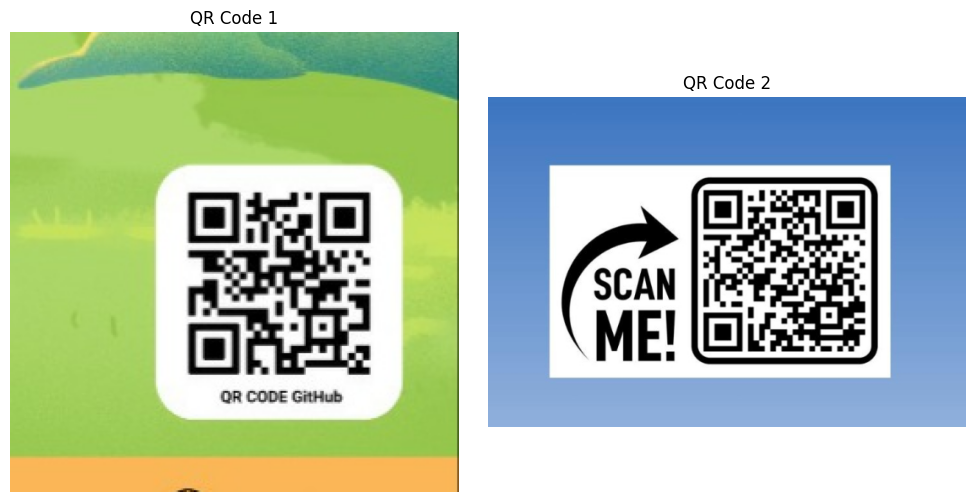

In [3]:
# Path ke folder data dan file gambar
image_path1 = os.path.join('data', 'qrcode1.jpeg')
image_path2 = os.path.join('data', 'qrcode2.png')

# Memuat gambar
image1 = cv2.imread(image_path1)
image2 = cv2.imread(image_path2)

# Plot kedua gambar
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
axes[0].set_title('QR Code 1')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
axes[1].set_title('QR Code 2')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### **Membaca QR Code**

In [4]:
# Deteksi dan baca QR code menggunakan pyzbar
decoded_qr1 = decode(image1)
print (decoded_qr1)

[Decoded(data=b'https://qrco.de/bgoPAv', type='QRCODE', rect=Rect(left=100, top=89, width=99, height=100), polygon=[Point(x=100, y=89), Point(x=100, y=189), Point(x=199, y=189), Point(x=198, y=89)], quality=1, orientation='UP')]


In [5]:
# Deteksi menggunakan cv2
qr_detector = cv2.QRCodeDetector()

# Detect and decode the QR code
qr_data, points, _ = qr_detector.detectAndDecode(image1)

# Print the decoded data and points
print(f"Decoded QR Data: {qr_data}")
print(f"QR Code Points: {points}")

Decoded QR Data: https://qrco.de/bgoPAv
QR Code Points: [[[ 99.        89.      ]
  [199.        89.      ]
  [199.       192.      ]
  [ 97.990204 188.96971 ]]]


### **Deteksi QR Code**

Decoded Data: https://bit.ly/formseminarproposalpgsd


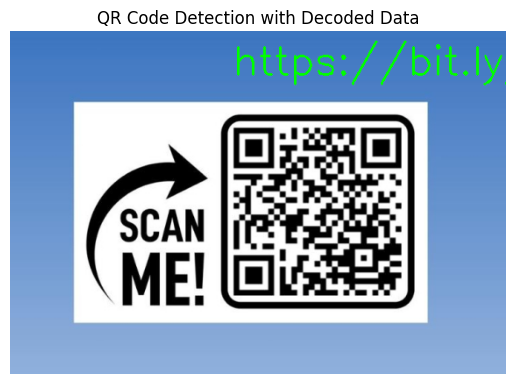

In [6]:
# Deteksi dan baca QR code menggunakan pyzbar
imagetext = image2.copy()
decoded_qr2 = decode(imagetext)

# Loop melalui hasil deteksi
for obj in decoded_qr2:
    points = obj.polygon
    if len(points) == 4:
        pts = np.array([[p.x, p.y] for p in points], dtype=np.int32)
        cv2.polylines(image2, [pts], isClosed=True, color=(0, 255, 0), thickness=3)

    # Data yang didekodekan
    qr_data = obj.data.decode('utf-8')
    print(f"Decoded Data: {qr_data}")

    x, y = obj.rect.left, obj.rect.top
    cv2.putText(imagetext, qr_data, (x, y - 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 2)

# Tampilkan gambar dengan hasil pembacaan
plt.imshow(cv2.cvtColor(imagetext, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('QR Code Detection with Decoded Data')
plt.show()

In [7]:
# Menggunakan kamera secara real-time
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Kamera tidak bisa dibuka")
else:
    print("Pencet 'ESC' atau 'q' untuk keluar.")

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    if not ret:
        print("Error: Gagal mengambil frame kamera.")
        break

    # Decode QR code
    decoded_qrs = decode(frame)

    for obj in decoded_qrs:
        points = obj.polygon
        if len(points) == 4:
            pts = np.array([[p.x, p.y] for p in points], dtype=np.int32)
            cv2.polylines(frame, [pts], isClosed=True, color=(0, 255, 0), thickness=3)

        # Data yang didekodekan
        qr_data = obj.data.decode('utf-8')
        print(f"Decoded Data: {qr_data}")

        x, y = obj.rect.left, obj.rect.top
        cv2.putText(frame, qr_data, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # Tampilkan hasil
    cv2.imshow('QR Code Detection', frame)

    # Exit on 'ESC' or 'q'
    key = cv2.waitKey(1) & 0xFF
    if key == 27 or key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Pencet 'ESC' atau 'q' untuk keluar.
Decoded Data: https://forms.cloud.microsoft/Pages/ResponsePage.aspx?id=gxFu22VMXECCznzVP6bp3CiMxgw51hBPhqQI_uX8hrRUOEFBNEY0QlhURUtWOVZPTzVZVUtXVkVUVi4u&origin=QRCode
Decoded Data: https://forms.cloud.microsoft/Pages/ResponsePage.aspx?id=gxFu22VMXECCznzVP6bp3CiMxgw51hBPhqQI_uX8hrRUOEFBNEY0QlhURUtWOVZPTzVZVUtXVkVUVi4u&origin=QRCode
Decoded Data: https://forms.cloud.microsoft/Pages/ResponsePage.aspx?id=gxFu22VMXECCznzVP6bp3CiMxgw51hBPhqQI_uX8hrRUOEFBNEY0QlhURUtWOVZPTzVZVUtXVkVUVi4u&origin=QRCode
Decoded Data: https://forms.cloud.microsoft/Pages/ResponsePage.aspx?id=gxFu22VMXECCznzVP6bp3CiMxgw51hBPhqQI_uX8hrRUOEFBNEY0QlhURUtWOVZPTzVZVUtXVkVUVi4u&origin=QRCode
Decoded Data: https://forms.cloud.microsoft/Pages/ResponsePage.aspx?id=gxFu22VMXECCznzVP6bp3CiMxgw51hBPhqQI_uX8hrRUOEFBNEY0QlhURUtWOVZPTzVZVUtXVkVUVi4u&origin=QRCode
Decoded Data: https://forms.cloud.microsoft/Pages/ResponsePage.aspx?id=gxFu22VMXECCznzVP6bp3CiMxgw51hBPhqQI_uX8hrRUOEFBNEY0QlhURUtWOVZ

> **Pertanyaan:** Bagaimana jika untuk mendeteksi Barcode?

Tidak ada barcode atau QR code terdeteksi.


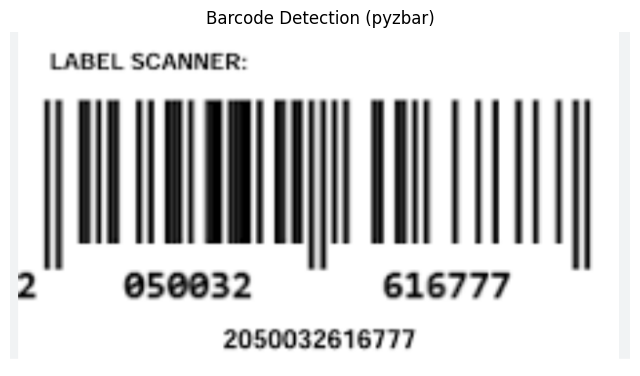

In [6]:
import os
# Path gambar di folder data
image_path = os.path.join("data", "bercode2.png")

# Pastikan file ada
if not os.path.exists(image_path):
    print(f"Error: File tidak ditemukan di {image_path}")
    exit()

# Baca gambar
image = cv2.imread(image_path)
if image is None:
    print("Error: Gagal membaca gambar.")
    exit()

# Decode barcode / QR code
decoded_objects = decode(image)

if not decoded_objects:
    print("Tidak ada barcode atau QR code terdeteksi.")
else:
    for obj in decoded_objects:
        # Titik-titik posisi barcode
        points = obj.polygon
        if len(points) == 4:
            pts = np.array([[p.x, p.y] for p in points], dtype=np.int32)
            cv2.polylines(image, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

        # Data dan tipe barcode
        barcode_data = obj.data.decode('utf-8')
        barcode_type = obj.type
        print(f"Tipe: {barcode_type}, Data: {barcode_data}")

        # Tambahkan teks di atas barcode
        x, y = obj.rect.left, obj.rect.top
        cv2.putText(image, f"{barcode_type}: {barcode_data}", (x, y - 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

# Konversi BGR → RGB agar warna tampil benar di matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Tampilkan dengan plt
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Barcode Detection (pyzbar)")
plt.show()


## **Landmark Wajah**

Landmark wajah adalah teknik untuk mengenali titik-titik penting pada wajah, seperti mata, hidung, bibir, dan rahang, biasanya berjumlah 68 titik atau lebih tergantung model. Deteksi ini dapat dilakukan menggunakan berbagai library seperti `Dlib`, `MediaPipe`, atau `OpenCV`, dan sering digunakan untuk analisis ekspresi, pelacakan wajah, atau efek augmented reality.

Setiap library memiliki jumlah dan posisi landmark wajah yang berbeda tergantung model yang digunakan:
1. `Dlib` → biasanya mendeteksi 68 landmark, mencakup detail rahang, mata, hidung, dan bibir
2. `MediaPipe` → jauh lebih detail, memiliki 468 titik (3D), cocok untuk aplikasi AR dan pelacakan ekspresi wajah secara real-time.
3. `OpenCV` → tidak punya deteksi landmark bawaan, tetapi bisa menggunakan model eksternal (seperti lbfmodel.yaml dari modul face OpenCV-contrib)

In [7]:
import mediapipe as mp

print(mp.__version__)
print(hasattr(mp, "solutions"))
print(mp.solutions)

0.10.9
True
<module 'mediapipe.python.solutions' from 'c:\\Users\\mrasu\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\mediapipe\\python\\solutions\\__init__.py'>


### **Membaca Landmark Wajah Menggunakan MediaPipe**

In [8]:
import cv2
import mediapipe as mp

# Inisialisasi MediaPipe
mp_drawing = mp.solutions.drawing_utils
mp_face_mesh = mp.solutions.face_mesh

# Setup FaceMesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Setup kamera
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Kamera tidak bisa dibuka")
    exit()

print("Tekan q untuk keluar")

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Flip kamera agar seperti mirror
    frame = cv2.flip(frame, 1)

    # Convert ke RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Proses Face Mesh
    results = face_mesh.process(rgb_frame)

    h, w, _ = frame.shape

    # Jika wajah terdeteksi
    if results.multi_face_landmarks:

        for face_landmarks in results.multi_face_landmarks:

            # Gambar mesh wajah
            mp_drawing.draw_landmarks(
                image=frame,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION
            )

            # Tampilkan nomor landmark
            for idx, lm in enumerate(face_landmarks.landmark):

                x = int(lm.x * w)
                y = int(lm.y * h)

                cv2.putText(
                    frame,
                    str(idx),
                    (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.3,
                    (0, 255, 0),
                    1
                )

    cv2.imshow("Face Mesh", frame)

    # Keluar jika tekan q
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Tekan q untuk keluar


### **Membaca Landmark Wajah Menggunakan dlib**

In [9]:
import os
import urllib.request
import bz2

# ========================================
# PATH MODEL
# ========================================

predictor_path = os.path.join(
    os.getcwd(),
    'shape_predictor_68_face_landmarks.dat'
)

print("Lokasi model:")
print(predictor_path)

# ========================================
# URL MODEL DLIB
# ========================================

predictor_url = (
    "https://github.com/davisking/dlib-models/raw/master/"
    "shape_predictor_68_face_landmarks.dat.bz2"
)

# ========================================
# DOWNLOAD MODEL JIKA BELUM ADA
# ========================================

if not os.path.exists(predictor_path):

    print("Model landmark belum ada.")
    print("Mengunduh model dari GitHub...")

    compressed_path = predictor_path + ".bz2"

    urllib.request.urlretrieve(
        predictor_url,
        compressed_path
    )

    print("Download selesai.")
    print("Ekstraksi file...")

    with bz2.open(compressed_path, 'rb') as f_in:
        with open(predictor_path, 'wb') as f_out:
            f_out.write(f_in.read())

    os.remove(compressed_path)

    print("Model berhasil diekstrak.")

else:
    print("Model landmark sudah tersedia.")

Lokasi model:
c:\Users\mrasu\Pengolahan_Multimedia\shape_predictor_68_face_landmarks.dat
Model landmark sudah tersedia.


In [11]:
import cv2
import mediapipe as mp

# ========================================
# INISIALISASI MEDIAPIPE
# ========================================

mp_face_mesh = mp.solutions.face_mesh
mp_draw = mp.solutions.drawing_utils

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# ========================================
# BUKA KAMERA
# ========================================

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Kamera tidak bisa dibuka")
    exit()

print("Tekan q untuk keluar")

# ========================================
# LOOP CAMERA
# ========================================

while True:

    ret, frame = cap.read()

    if not ret:
        print("Error: Gagal membaca frame")
        break

    # Flip kamera
    frame = cv2.flip(frame, 1)

    # Convert BGR ke RGB
    rgb_frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    # Process face mesh
    results = face_mesh.process(rgb_frame)

    # Jika wajah terdeteksi
    if results.multi_face_landmarks:

        for face_landmarks in results.multi_face_landmarks:

            # ========================================
            # GAMBAR LANDMARK
            # ========================================

            mp_draw.draw_landmarks(
                image=frame,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_draw.DrawingSpec(
                    color=(0, 255, 0),
                    thickness=1,
                    circle_radius=1
                )
            )

            # ========================================
            # TAMPILKAN NOMOR TITIK
            # ========================================

            h, w, c = frame.shape

            for idx, landmark in enumerate(face_landmarks.landmark):

                x = int(landmark.x * w)
                y = int(landmark.y * h)

                # Titik kecil
                cv2.circle(
                    frame,
                    (x, y),
                    1,
                    (0, 0, 255),
                    -1
                )

                # Nomor titik
                cv2.putText(
                    frame,
                    str(idx),
                    (x + 2, y - 2),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.3,
                    (255, 255, 0),
                    1
                )

    # ========================================
    # TAMPILKAN WINDOW
    # ========================================

    cv2.imshow(
        "MediaPipe Face Mesh",
        frame
    )

    # Keluar dengan tombol q
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ========================================
# RELEASE
# ========================================

cap.release()
cv2.destroyAllWindows()

Tekan q untuk keluar


## **Image Overlay Ke Wajah**

In [13]:
import cv2
import mediapipe as mp
import numpy as np
import os

# ========================================
# LOAD GAMBAR KACAMATA
# ========================================

glasses_path = os.path.join(
    "data",
    "glasses.png"
)

glasses = cv2.imread(
    glasses_path,
    cv2.IMREAD_UNCHANGED
)

if glasses is None:
    print("Error: gambar kacamata tidak ditemukan")
    exit()

# ========================================
# INISIALISASI MEDIAPIPE
# ========================================

mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# ========================================
# BUKA KAMERA
# ========================================

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Kamera tidak bisa dibuka")
    exit()

print("Tekan q untuk keluar")

# ========================================
# LOOP CAMERA
# ========================================

while True:

    ret, frame = cap.read()

    if not ret:
        print("Error membaca frame")
        break

    # Mirror kamera
    frame = cv2.flip(frame, 1)

    # Convert ke RGB
    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    # Deteksi wajah
    results = face_mesh.process(rgb)

    # Jika wajah terdeteksi
    if results.multi_face_landmarks:

        for face_landmarks in results.multi_face_landmarks:

            h, w, c = frame.shape

            # ========================================
            # TITIK MATA
            # ========================================

            # Mata kiri
            left_eye = face_landmarks.landmark[33]

            # Mata kanan
            right_eye = face_landmarks.landmark[263]

            # Convert ke pixel
            left_x = int(left_eye.x * w)
            left_y = int(left_eye.y * h)

            right_x = int(right_eye.x * w)
            right_y = int(right_eye.y * h)

            # ========================================
            # HITUNG UKURAN KACAMATA
            # ========================================

            eye_distance = int(
                np.sqrt(
                    (right_x - left_x) ** 2 +
                    (right_y - left_y) ** 2
                )
            )

            glasses_width = int(2.2 * eye_distance)

            aspect_ratio = glasses.shape[0] / glasses.shape[1]

            glasses_height = int(
                glasses_width * aspect_ratio
            )

            # Titik tengah mata
            center_x = int((left_x + right_x) / 2)
            center_y = int((left_y + right_y) / 2)

            # Posisi overlay
            x1 = int(center_x - glasses_width / 2)
            y1 = int(center_y - glasses_height / 2)

            x2 = x1 + glasses_width
            y2 = y1 + glasses_height

            # ========================================
            # BATAS FRAME
            # ========================================

            if (
                x1 < 0 or
                y1 < 0 or
                x2 > w or
                y2 > h
            ):
                continue

            # ========================================
            # RESIZE KACAMATA
            # ========================================

            resized_glasses = cv2.resize(
                glasses,
                (glasses_width, glasses_height)
            )

            # Pisahkan channel
            b, g, r, a = cv2.split(
                resized_glasses
            )

            overlay_color = cv2.merge(
                (b, g, r)
            )

            alpha_mask = a / 255.0

            # Area wajah
            roi = frame[y1:y2, x1:x2]

            # Blend
            for c in range(3):

                roi[:, :, c] = (
                    alpha_mask * overlay_color[:, :, c] +
                    (1 - alpha_mask) * roi[:, :, c]
                )

            frame[y1:y2, x1:x2] = roi

    # ========================================
    # TAMPILKAN FRAME
    # ========================================

    cv2.imshow(
        "Face Filter Glasses",
        frame
    )

    # Tombol keluar
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ========================================
# RELEASE
# ========================================

cap.release()
cv2.destroyAllWindows()

Tekan q untuk keluar


In [1]:
import cv2
import mediapipe as mp
import numpy as np
import os

# ========================================
# LOAD GAMBAR LIPSTICK
# ========================================

lipstick_path = os.path.join(
    "data",
    "lipstick.png"
)

lipstick = cv2.imread(
    lipstick_path,
    cv2.IMREAD_UNCHANGED
)

if lipstick is None:
    print("Error: gambar lipstick tidak ditemukan")
    exit()

# ========================================
# CEK CHANNEL GAMBAR
# ========================================

if lipstick.shape[2] == 4:

    # PNG transparan
    b, g, r, a = cv2.split(lipstick)

    lipstick_rgb = cv2.merge((b, g, r))

    alpha = a / 255.0

else:

    # JPG / tanpa alpha
    lipstick_rgb = lipstick

    alpha = np.ones(
        lipstick.shape[:2],
        dtype=float
    )

# ========================================
# INISIALISASI MEDIAPIPE
# ========================================

mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# ========================================
# BUKA KAMERA
# ========================================

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Kamera tidak bisa dibuka")
    exit()

print("Tekan q untuk keluar")

# ========================================
# LOOP CAMERA
# ========================================

while True:

    ret, frame = cap.read()

    if not ret:
        print("Error membaca frame")
        break

    # Flip kamera
    frame = cv2.flip(frame, 1)

    # Convert BGR ke RGB
    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    # Process wajah
    results = face_mesh.process(rgb)

    # ========================================
    # DETEKSI WAJAH
    # ========================================

    if results.multi_face_landmarks:

        for face_landmarks in results.multi_face_landmarks:

            h, w, c = frame.shape

            # ========================================
            # TITIK BIBIR
            # ========================================

            # Kiri
            left_lip = face_landmarks.landmark[61]

            # Kanan
            right_lip = face_landmarks.landmark[291]

            # Atas
            top_lip = face_landmarks.landmark[13]

            # Bawah
            bottom_lip = face_landmarks.landmark[14]

            # ========================================
            # CONVERT KE PIXEL
            # ========================================

            left_x = int(left_lip.x * w)
            left_y = int(left_lip.y * h)

            right_x = int(right_lip.x * w)
            right_y = int(right_lip.y * h)

            top_x = int(top_lip.x * w)
            top_y = int(top_lip.y * h)

            bottom_x = int(bottom_lip.x * w)
            bottom_y = int(bottom_lip.y * h)

            # ========================================
            # HITUNG UKURAN LIPSTICK
            # ========================================

            lip_width = int(
                np.sqrt(
                    (right_x - left_x) ** 2 +
                    (right_y - left_y) ** 2
                ) * 1.7
            )

            lip_height = int(
                np.sqrt(
                    (bottom_x - top_x) ** 2 +
                    (bottom_y - top_y) ** 2
                ) * 3
            )

            # Hindari resize error
            lip_width = max(1, lip_width)
            lip_height = max(1, lip_height)

            # ========================================
            # POSISI TENGAH BIBIR
            # ========================================

            center_x = int((top_x + bottom_x) / 2)
            center_y = int((top_y + bottom_y) / 2)

            # ========================================
            # HITUNG AREA OVERLAY
            # ========================================

            x1 = int(center_x - lip_width / 2)
            y1 = int(center_y - lip_height / 2)

            x2 = x1 + lip_width
            y2 = y1 + lip_height

            # ========================================
            # BATAS FRAME
            # ========================================

            if (
                x1 < 0 or
                y1 < 0 or
                x2 > w or
                y2 > h
            ):
                continue

            # ========================================
            # RESIZE LIPSTICK
            # ========================================

            resized_lipstick = cv2.resize(
                lipstick_rgb,
                (lip_width, lip_height)
            )

            resized_alpha = cv2.resize(
                alpha,
                (lip_width, lip_height)
            )

            resized_alpha = resized_alpha[:, :, None]

            # ========================================
            # ROI FRAME
            # ========================================

            roi = frame[y1:y2, x1:x2]

            # ========================================
            # BLENDING
            # ========================================

            blended = (
                resized_alpha * resized_lipstick +
                (1 - resized_alpha) * roi
            ).astype(np.uint8)

            frame[y1:y2, x1:x2] = blended

    # ========================================
    # TAMPILKAN FRAME
    # ========================================

    cv2.imshow(
        "Face Filter Lipstick",
        frame
    )

    # ========================================
    # KELUAR DENGAN Q
    # ========================================

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ========================================
# RELEASE
# ========================================

cap.release()
cv2.destroyAllWindows()

Tekan q untuk keluar
